In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.neighbors import KernelDensity

from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM
from msi.utils import input_output, plotting, mcmc, preprocessing
from msfm.utils import prior, parameters, files

24-01-25 06:02:21   imports.py INF   Setting up healpy to run on 32 CPUs 


# network predictions

### choose a run

### v3

In [3]:
# base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# # base_dir = "/Users/arne/data/DESY3/models/v3/"

In [4]:
# # clustering only

# # legacy vanilla
# # model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# # new vanilla
# # model_dir = "2023-08-17_08-50-56_resnet_vanilla"

# # Jacobian unlike the identity
# # model_dir = "2023-08-17_08-23-47_resnet_vanilla"

# # mean subtracted from all maps
# # model_dir = "2023-08-17_08-38-03_resnet_vanilla"

# # mean subtracted and divide by std for all maps
# model_dir = "2023-08-17_08-19-09_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [5]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [6]:
# # lensing only
# model_dir = "2023-05-29_09-55-49_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [7]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

### v4

In [8]:
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

In [9]:
# # clustering only

# # large_scales (8 Mpc/h)
# model_dir = "2023-08-25_05-40-02_resnet_vanilla"

# # large scales (12 Mpc/h) and first redshift bin only
# model_dir = "2023-08-29_08-42-16_resnet_vanilla"

# large scales (12 Mpc/h) and third redshift bin only
# model_dir = "2023-08-30_04-21-53_resnet_vanilla"

# # extra large scales (8 Mpc/h, but no factor of pi as with Al)
# model_dir = "2023-08-30_09-31-59_resnet_vanilla"

# GRF, 8 Mpc/h "physical"
# model_dir = "grf/2023-09-06_03-29-03_resnet_vanilla"
# shorter run
# model_dir  = "grf/2023-09-06_09-08-40_resnet_vanilla"
# slightly different network architectures
# model_dir = "grf/2023-09-07_08-08-00_resnet_vanilla"
# model_dir = "grf/2023-09-07_08-09-35_resnet_vanilla"
# only 1st noise realization
# model_dir = "grf/2023-09-07_23-47-11_resnet_vanilla"
# fixed numpy seed
# model_dir = "grf/2023-09-08_07-32-58_resnet_vanilla"

# original data, 8 Mpc/h "physical", for direct comparison with immediately above
# model_dir = "2023-09-06_09-45-08_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "bg", "n_bg"]

In [10]:
# lensing only

# large_scales (6 Mpc/h)
# model_dir = "2023-08-28_04-29-33_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [11]:
# combined probes
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# all parameters
model_dir = "2023-08-31_03-29-47_resnet_vanilla"

n_steps = 20000
params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v5

In [12]:
# # clustering (linear bias)
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v5/linear_bias"
# model_dir = "2023-10-02_19-48-47_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [13]:
# # clustering (quadratic bias)
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/quadratic_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v5/quadratic_bias_v2"
# model_dir = "2023-10-03_00-16-59_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg", "bg2", "n_bg2"]

In [14]:
# clustering (stochasticity)
# base_dir = "/pscratch/sd/a/athomsen/run_files/v5/stochasticity"

# n_steps = 40000
# params = ["Om", "s8", "bg", "n_bg"]

In [15]:
# lensing

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [16]:
# combined

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

In [17]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# likelihood loss
# model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

n_steps = 100000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

In [18]:
# # lensing
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# # delta loss
# model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# # MSE loss
# # model_dir = "mse/2024-01-08_03-05-03_resnet_vanilla"

# # likelihood loss
# # model_dir = "mse/2024-01-05_22-04-15_resnet_vanilla"
# # model_dir = "mse/2024-01-08_06-13-14_resnet_vanilla"

# n_steps = 100000
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

In [19]:
# # clustering
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/clustering_only"

# # # delta loss

# # # MSE loss
# # model_dir =

# # # likelihood loss
# model_dir = "mse/2024-01-08_10-05-55_resnet_vanilla"

# n_steps = 40000
# params = ["Om", "s8", "w0", "bg", "n_bg"]

### general

In [20]:
# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir, model_dir, n_steps, n_params=len(params)
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_gaussians"

24-01-25 06:02:23 input_output INF   Array shapes: 
24-01-25 06:02:23 input_output INF   fiducial/vali/pred = (4, 5) 
24-01-25 06:02:23 input_output INF   fiducial/vali/i_example = (4,) 
24-01-25 06:02:23 input_output INF   fiducial/vali/i_noise = (4,) 
24-01-25 06:02:23 input_output INF   grid/pred          = (2500, 48, 5) 
24-01-25 06:02:23 input_output INF   grid/cosmo         = (2500, 5) 
24-01-25 06:02:23 input_output INF   grid/i_example     = (2500, 48) 
24-01-25 06:02:23 input_output INF   grid/i_noise       = (2500, 48) 
24-01-25 06:02:23 input_output INF   grid/i_sobol       = (2500,) 


24-01-25 06:02:23 preprocessin INF   Shapes after concatenation and selection: 
24-01-25 06:02:23 preprocessin INF   fidu_preds  = (4, 5) 
24-01-25 06:02:23 preprocessin INF   grid_preds  = (120000, 5) 
24-01-25 06:02:23 preprocessin INF   grid_cosmos = (120000, 5) 


# Gaussian mixture model

In [21]:
# preds = np.concatenate(grid_preds, axis=0)
# thetas = np.repeat(grid_cosmos, preds.shape[0]//grid_cosmos.shape[0], axis=0)

# print(preds.shape)
# print(thetas.shape)

In [22]:
# p(y | x) <=> p(summary | theta)
model = ConditionalGMM(
    # theta
    x_dim=grid_cosmos.shape[1],
    # summary
    y_dim=grid_preds.shape[1],
    out_dir="/pscratch/sd/a/athomsen/run_files/debug/GMM",
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

24-01-25 06:02:25 gaussian_mix INF   Created GMM model with n_params = 220500 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 5)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1536      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

In [23]:
fit_history = model.fit(
    x=grid_cosmos,
    y=grid_preds,
    epochs=1000,
    batch_size=10000,
    early_stopping_callback=True,
    learning_rate_callback=True,
)

24-01-25 06:02:25 gaussian_mix INF   Fitted the x and y scalers 


epoch:  76%|███████▌  | 756/1000 [00:45<00:13, 17.81it/s, loss=-17.5, val_loss=-16.9, lr=2.38e-5] 

Restoring model weights from the end of the best epoch: 657.


epoch:  76%|███████▌  | 757/1000 [00:45<00:13, 17.80it/s, loss=-17.5, val_loss=-16.9, lr=2.38e-5]

Epoch 757: early stopping


epoch:  76%|███████▌  | 757/1000 [00:45<00:14, 16.60it/s, loss=-17.5, val_loss=-16.9, lr=2.38e-5]

24-01-25 06:03:10 gaussian_mix INF   Finished training 


24-01-25 06:03:10 gaussian_mix INF   Saved the model in /pscratch/sd/a/athomsen/run_files/debug/GMM 


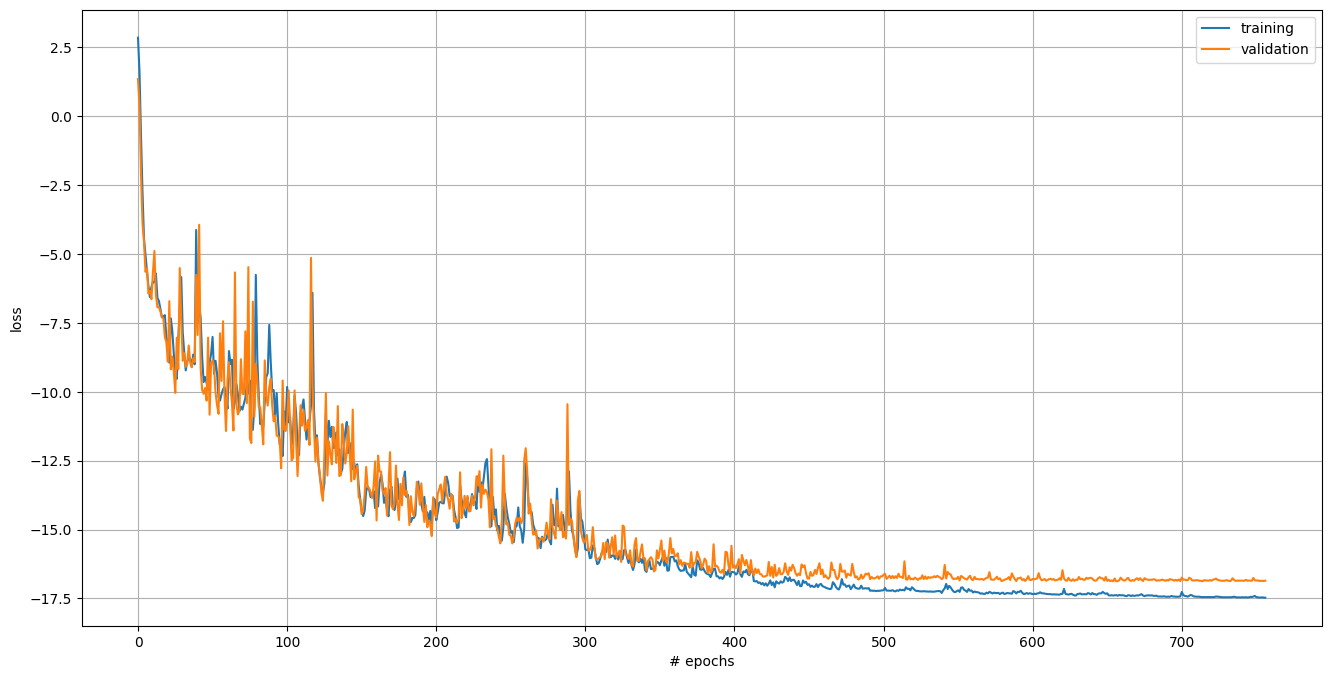

In [24]:
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

### observation

In [25]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
obs_pred = fidu_preds[i_obs]

Using the example index 0


## MCMC

In [26]:
tf_pred = tf.cast(obs_pred, dtype=tf.float32)
tf_pred = tf.expand_dims(tf_pred, axis=0)

def log_likelihood(X): 
        
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=conf)

    return log_prob

In [27]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
)

24-01-25 06:03:11      mcmc.py INF   Initial values in prior: True 
24-01-25 06:03:11      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-01-25 06:03:22      mcmc.py INF   Starting the main MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [01:51<00:00,  8.99it/s]

24-01-25 06:05:13      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/chain_100000_gaussians.npy 


## plot

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

24-01-25 06:05:18  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/contours_100000_gaussians.png 


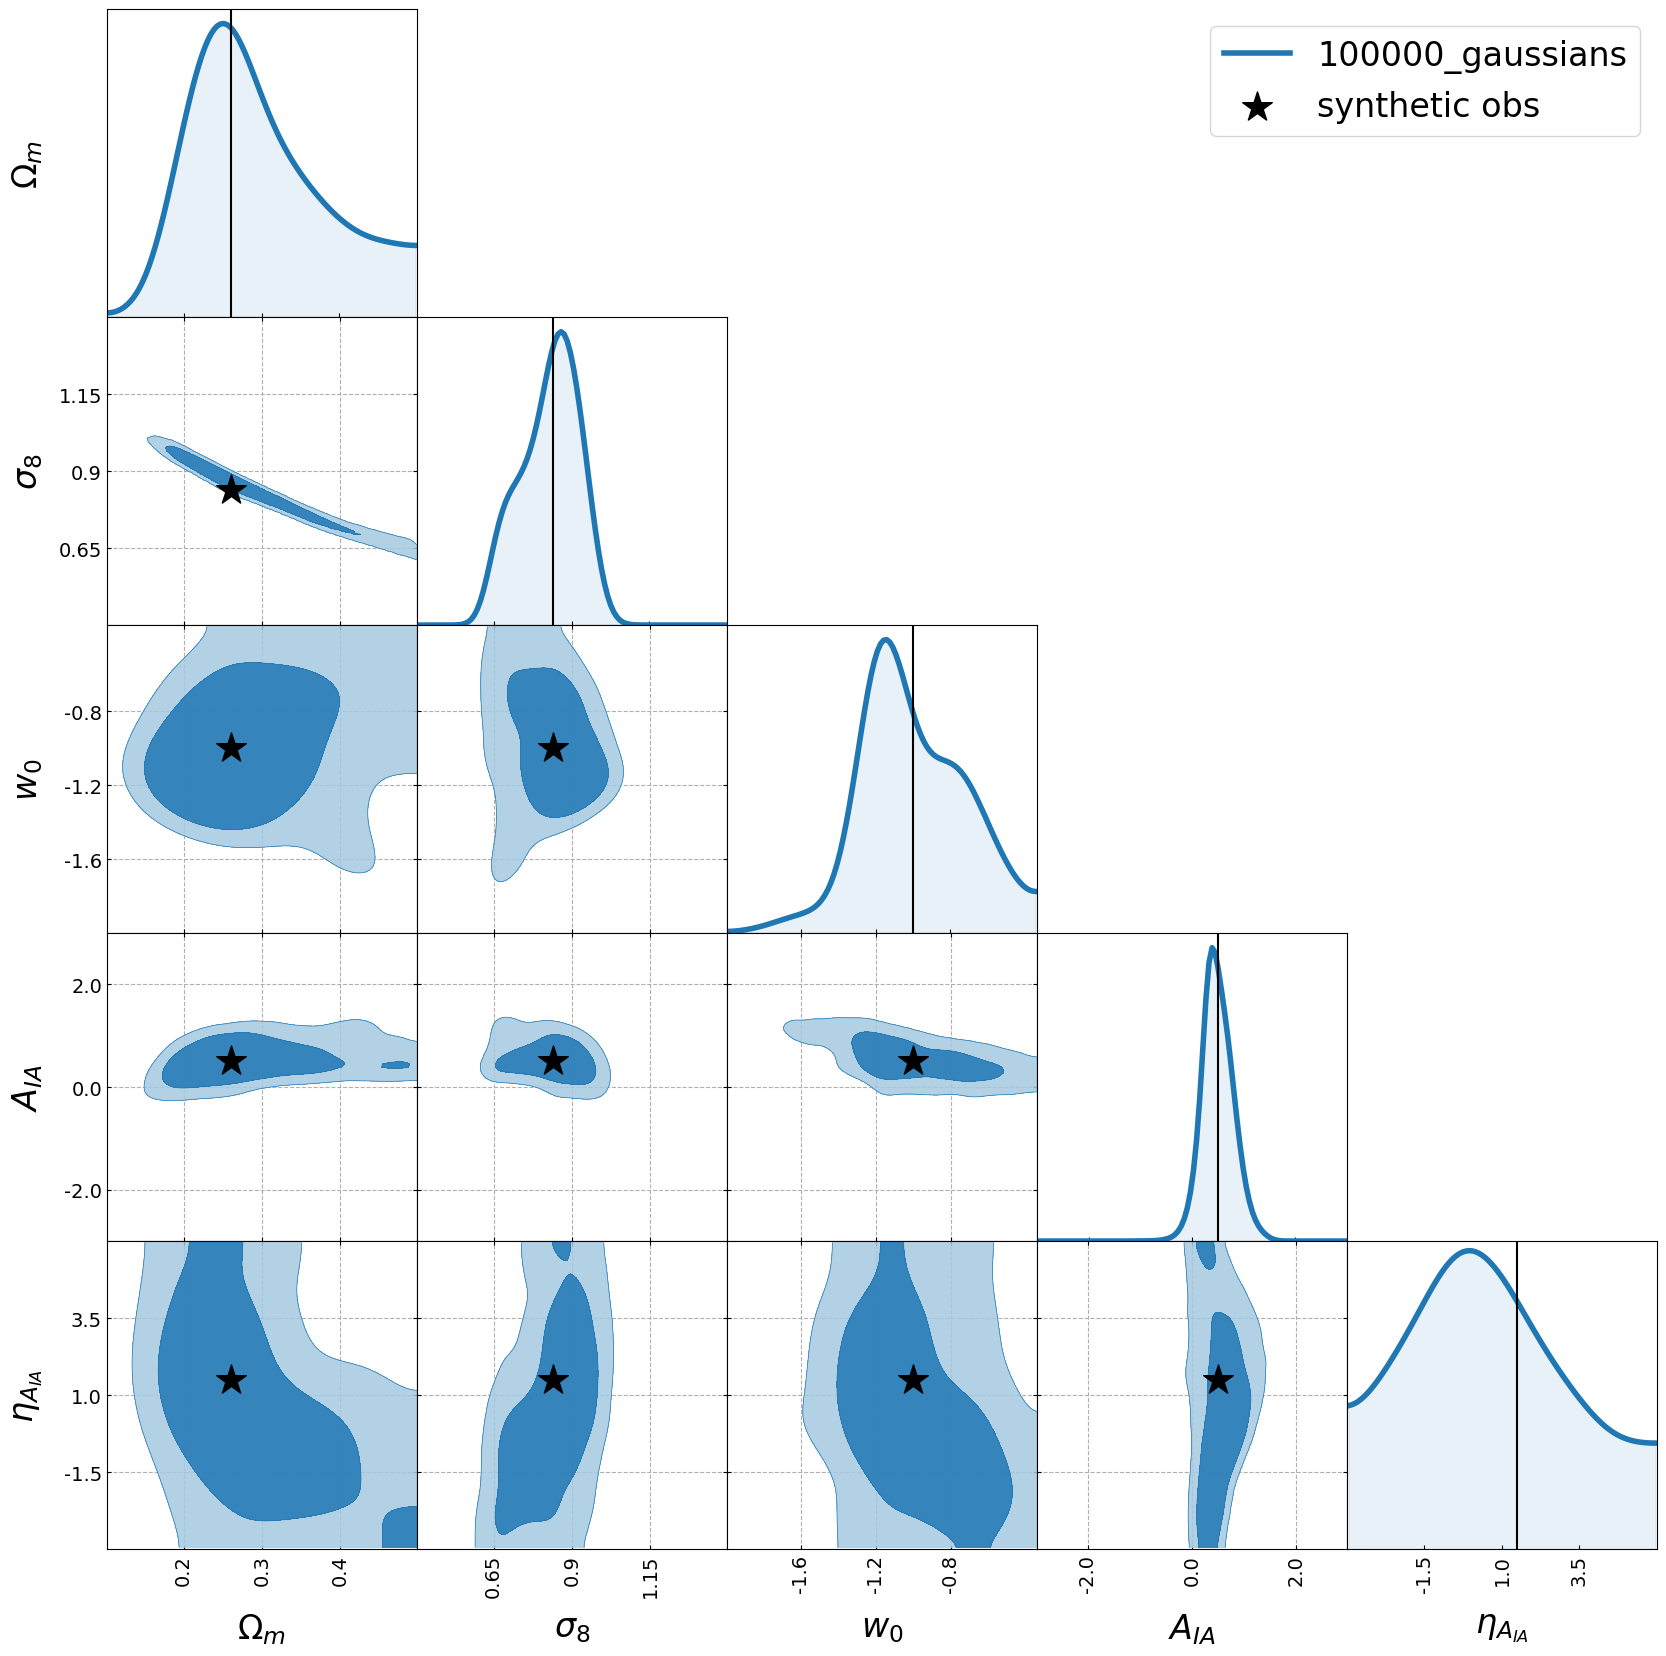

In [28]:
plotting.plot_chains(
    chain, 
    params, 
    conf=conf,
    out_dir=out_dir, 
    plot_labels=label,
    file_label=label,
    # fiducial_point=fiducial_point,
)